# Self-Supervised Nuclei Segmentation: main experiment

Pipeline:
1. **Phase 1: self-supervised pretraining** of a U-Net encoder on unlabeled image crops with two pretext tasks: a **scale-wise triplet loss** (shared-weight encoder on anchor / positive / negative crops) and a **counting-ranking** loss.
2. **Phase 2: fine-tuning** the full U-Net for nuclei segmentation using only **10% of the labeled training data**.
3. **Phase 3: baseline**, the same U-Net trained on the same 10% without self-supervised pretraining.

Evaluation: Dice coefficient and Kaggle-style mean average precision (mAP over IoU thresholds).

Data paths point to Google Drive zips of the Kaggle Data Science Bowl 2018 (stage 1) data; see the repository README for setup.

In [ ]:
#GPU count and name
!nvidia-smi -L

GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-dbd0687c-4685-f899-d9bc-8100bbf6a33d)


In [ ]:
from torch.utils.data import DataLoader, Dataset
import torch
import os
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import random
import torch.utils.data as data
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
from tqdm import tqdm
import cv2
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir Tmp
!mkdir Tmp/Self
!mkdir Tmp/UNET
!unzip drive/My\ Drive/Kaggle/Stage1_Self.zip -d Tmp/Self
!unzip drive/My\ Drive/Kaggle/Stage1_UNET.zip -d Tmp/UNET
!mkdir Data
!mkdir Data/Self
!mkdir Data/Self/Images
!mkdir Data/Self/Images/train/
!mkdir Data/Self/Labels
!mkdir Data/Self/Labels/train/
!mkdir Data/UNET
!mkdir Data/UNET/Images
!mkdir Data/UNET/Images/train/
!mkdir Data/UNET/Labels
!mkdir Data/UNET/Labels/train/

!mv Tmp/Self/Data/Images/* Data/Self/Images/train/
!mv Tmp/Self/Data/Labels/* Data/Self/Labels/train/
!mv Tmp/UNET/Data/Images/* Data/UNET/Images/train/
!mv Tmp/UNET/Data/Labels/* Data/UNET/Labels/train/
!rm -r Tmp

Archive:  drive/My Drive/Kaggle/Stage1_Self.zip
   creating: Tmp/Self/Data/
   creating: Tmp/Self/Data/Images/
  inflating: Tmp/Self/Data/Images/1027.png  
  inflating: Tmp/Self/Data/Images/477.png  
  inflating: Tmp/Self/Data/Images/420.png  
  inflating: Tmp/Self/Data/Images/675.png  
  inflating: Tmp/Self/Data/Images/19.png  
  inflating: Tmp/Self/Data/Images/279.png  
  inflating: Tmp/Self/Data/Images/302.png  
  inflating: Tmp/Self/Data/Images/227.png  
  inflating: Tmp/Self/Data/Images/532.png  
  inflating: Tmp/Self/Data/Images/1119.png  
  inflating: Tmp/Self/Data/Images/465.png  
  inflating: Tmp/Self/Data/Images/948.png  
  inflating: Tmp/Self/Data/Images/800.png  
  inflating: Tmp/Self/Data/Images/1018.png  
  inflating: Tmp/Self/Data/Images/698.png  
  inflating: Tmp/Self/Data/Images/1091.png  
  inflating: Tmp/Self/Data/Images/503.png  
  inflating: Tmp/Self/Data/Images/73.png  
  inflating: Tmp/Self/Data/Images/531.png  
  inflating: Tmp/Self/Data/Images/1005.png  
  infl

In [ ]:
dataset = 'Kaggle'

Data Loader Phase 1

In [ ]:
class Triplet_Dataset(Dataset):
    def __init__(self, dataset='Kaggle', train=True):
        self.train = train
        if dataset == 'MoNuSeg':
            self.TRAIN_DATA_PATH = "/content/Data/MoNuSegTrainingData/"
            self.TEST_DATA_PATH = "/content/Data/MoNuSegTestData/"
        elif dataset == 'Kaggle':
            self.TRAIN_DATA_PATH = "/content/Data/Self/Images/"
            self.TEST_DATA_PATH = "/content/Data/Self/Labels" ###############################################################
        self.train_data = torchvision.datasets.ImageFolder(root=self.TRAIN_DATA_PATH , )
        self.test_data = torchvision.datasets.ImageFolder(root=self.TEST_DATA_PATH)

    # returns 3 images
    def getTriplet(self, image):
        resize = transforms.Resize(size=(512, 512))
        image = resize(image)

        # Random crop, anchor
        i, j, h, w = transforms.RandomCrop.get_params(image, [384, 384])
        # print(i, j, w, h)
        anchor = TF.crop(image, i, j, h, w)

        # shift, positive
        i_shift = np.random.randint(-50, 50)
        j_shift = np.random.randint(-50, 50)

        new_i = i + i_shift
        new_j = j + j_shift
        if new_i < 0 or new_i + w > 512:
            new_i = i - i_shift
        if new_j < 0 or new_j + h > 512:
            new_j = j - j_shift
        pos = TF.crop(image, new_i, new_j, w, h)

        # negative
        scale = np.random.choice([6, 7, 8])
        i, j, h, w = transforms.RandomCrop.get_params(pos, [2 ** scale, 2 ** scale])
        neg = TF.crop(pos, i, j, h, w)
        resize = transforms.Resize(size=(384, 384))  # quality lowers a lot specially for 64*64 size
        neg = resize(neg)
        return anchor, pos, neg

    # returns tensor
    def getitem(self, index):
        if self.train:
          item = self.train_data[index]
        else:
          item = self.test_data[index]
        anchor, pos, neg = self.getTriplet(item[0])
        anchor = TF.to_tensor(anchor)
        pos = TF.to_tensor(pos)
        neg = TF.to_tensor(neg)
        return anchor, pos, neg

    def len(self):
        if self.train:
          return len(self.train_data)
        return len(self.test_data)

    # returns: List[Tuple[Tensor(anchor), Tensor(positive), Tensor(negative)]]
    def get_data_list(self):
        final_data = []
        for index in range(self.len()):
            final_data.append(self.getitem(index))
        return final_data

In [ ]:
# config
batch_size = 4
unet_batch_size = 2
num_workers = 0
validation_size = 0.1
validation_iteration = 5000
n_epochs = 10
learning_rate = 0.00001
weight_decay=1e-5
image_size = 512
n_channels = 3
n_classes = 1
base_channel = 64
seed = 1521
device = torch.device('cuda:0')

In [ ]:
# Data
d = Triplet_Dataset(dataset)
train_data = d.get_data_list()
# test_data = d.get_data_list('test')

# train_data to train and validation:
indices = list(range(len(train_data)))
np.random.seed(0)
np.random.shuffle(indices) # necessary?
split = int(np.floor(validation_size * len(train_data)))
train_index, validation_index = indices[split:], indices[:split]
# print(train_index)

train_sampler = SubsetRandomSampler(train_index)
validation_sampler = SubsetRandomSampler(validation_index)

# loaders
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=batch_size,
                                           sampler=train_sampler,
                                           num_workers=num_workers)
validation_loader = torch.utils.data.DataLoader(train_data,
                                                batch_size=batch_size,
                                                sampler=validation_sampler,
                                                num_workers=num_workers)

Data Loader Phase 2

In [ ]:
np.random.seed(0)
class Labeled_Dataset(Dataset):

    def __init__(self, dataset='Kaggle', train=True):
        self.train = train
        self.TRAIN_DATA_PATH = "/content/Data/Self/Images"
        self.TRAIN_LABEL_PATH = "/content/Data/Self/Labels"
        self.TEST_DATA_PATH = "/content/Data/UNET/Images"
        self.TEST_LABEL_PATH = "/content/Data/UNET/Labels"
        self.train_data = torchvision.datasets.ImageFolder(root=self.TRAIN_DATA_PATH)
        self.train_label = torchvision.datasets.ImageFolder(root=self.TRAIN_LABEL_PATH)
        self.test_data = torchvision.datasets.ImageFolder(root=self.TEST_DATA_PATH)
        self.test_label = torchvision.datasets.ImageFolder(root=self.TEST_LABEL_PATH)

    def getitem(self, index):
        if self.train:
          x = random.randint(9) + 1 ##################### I changed this part for random train data
          item = self.train_data[index*x]
          label = self.train_label[index*x]
        else:
          item = self.test_data[index]
          label = self.test_label[index]

        resize = transforms.Resize(size=(512, 512))
        grayscale = transforms.Grayscale(num_output_channels=1)

        item = resize(item[0])
        label = grayscale(resize(label[0]))
        item = TF.to_tensor(item)
        label = TF.to_tensor(label)

        return item, label

    def len(self):
        if self.train:
          return int(len(self.train_data) / 10) ################## I changed this part for 10% of train data
        return len(self.test_data)

    # returns: 
    def get_list(self):
        final_data = []
        final_label = []
        for index in range(self.len()):
            item, label = self.getitem(index)
            final_data.append([item,label])
        return final_data

10% of Train Data

In [ ]:
# Data
dataset = 'Kaggle'
td = Labeled_Dataset(dataset)
unet_train_data = td.get_list()


# train_data to train and validation:
indices = list(range(len(unet_train_data)))
np.random.seed(0)
np.random.shuffle(indices)
split = int(np.floor(validation_size * len(unet_train_data)))
u_train_index, u_validation_index = indices[split:], indices[:split]

u_train_sampler = SubsetRandomSampler(u_train_index)
u_validation_sampler = SubsetRandomSampler(u_validation_index)

# loaders
unet_train_loader = torch.utils.data.DataLoader(unet_train_data,
                                           batch_size=unet_batch_size,
                                           sampler=u_train_sampler,
                                           num_workers=num_workers)
unet_validation_loader = torch.utils.data.DataLoader(unet_train_data,
                                                batch_size=unet_batch_size,
                                                sampler=u_validation_sampler,
                                                num_workers=num_workers)

Test Data

In [ ]:
# Data
dataset = 'Kaggle'
testSet = Labeled_Dataset(dataset, train=False)
test_data = testSet.get_list()
test_loader = torch.utils.data.DataLoader(test_data,
                                          batch_size=unet_batch_size,
                                          num_workers=num_workers)

Architecture

In [ ]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# class full_UNet(nn.Module):
#     def __init__(self, n_channels=3, n_classes=3, base_channel=64, bilinear=True):
#         super(full_UNet, self).__init__()
#         self.n_channels = n_channels
#         self.n_classes = n_classes
#         self.bilinear = bilinear

#         self.inc = DoubleConv(n_channels, base_channel)
#         self.down1 = Down(base_channel, 2 * base_channel)
#         self.down2 = Down(2 * base_channel, 4 * base_channel)
#         self.down3 = Down(4 * base_channel, 8 * base_channel)
#         factor = 2 if bilinear else 1
#         self.down4 = Down(8 * base_channel, 16 * base_channel // factor)
#         self.up1 = Up(16 * base_channel, 8 * base_channel // factor, bilinear)
#         self.up2 = Up(8 * base_channel, 4 * base_channel // factor, bilinear)
#         self.up3 = Up(4 * base_channel, 2 * base_channel // factor, bilinear)
#         self.up4 = Up(2 * base_channel, base_channel, bilinear)
#         self.outc = OutConv(base_channel, n_classes)

#     def forward(self, x):
#         x1 = self.inc(x)
#         x2 = self.down1(x1)
#         x3 = self.down2(x2)
#         x4 = self.down3(x3)
#         x5 = self.down4(x4)
#         x = self.up1(x5, x4)
#         # shape = x5.shape
#         # x = self.up1(x5.view(-1, shape[1], shape[2], shape[3]), x4)
#         x = self.up2(x, x3)
#         x = self.up3(x, x2)
#         x = self.up4(x, x1)
#         x = self.outc(x)
#         return x


class Unet_encoder(nn.Module):
      def __init__(self, n_channels=3, base_channel=64, bilinear=True):
        super(Unet_encoder, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, base_channel)
        self.down1 = Down(base_channel, 2 * base_channel)
        self.down2 = Down(2 * base_channel, 4 * base_channel)
        self.down3 = Down(4 * base_channel, 8 * base_channel)
        factor = 2 if bilinear else 1
        self.down4 = Down(8 * base_channel, 16 * base_channel // factor)

      def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        return x5, [x1,x2,x3,x4]


class Unet(nn.Module):
    def __init__(self, n_classes=2, base_channel=64, encoder=Unet_encoder , bilinear=True):
        super(Unet, self).__init__()
        self.n_classes = n_classes
        self.bilinear = bilinear
        self.encoder = encoder

        factor = 2 if bilinear else 1
        self.up1 = Up(16 * base_channel, 8 * base_channel // factor, bilinear)
        self.up2 = Up(8 * base_channel, 4 * base_channel // factor, bilinear)
        self.up3 = Up(4 * base_channel, 2 * base_channel // factor, bilinear)
        self.up4 = Up(2 * base_channel, base_channel, bilinear)
        self.outc = OutConv(base_channel, n_classes)
    
    def forward(self, x):
        x5, [x1,x2,x3,x4] = self.encoder(x)
        h = self.up1(x5, x4)
        # shape = x5.shape
        # x = self.up1(x5.view(-1, shape[1], shape[2], shape[3]), x4)
        h = self.up2(h, x3)
        h = self.up3(h, x2)
        h = self.up4(h, x1)
        h = self.outc(h)
        return h

In [ ]:
class TripletNet(nn.Module):
    def __init__(self, Unet_encoder):
        super(TripletNet, self).__init__()
        self.Unet_encoder = Unet_encoder
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(294912, 256)     
        self.fc2 = nn.Linear(294912, 256)  
        self.fc3 = nn.Linear(294912, 256)                  
                                
    def forward(self, i1, i2, i3):
        weights = self.Unet_encoder(i1)[1]
        i1 = self.Unet_encoder(i1)[0]
        i1 = self.flatten(i1)
        E1 = self.fc1(i1)
        i2 = self.Unet_encoder(i2)[0]
        i2 = self.flatten(i2)
        E2 = self.fc1(i2)
        i3 = self.Unet_encoder(i3)[0]
        i3 = self.flatten(i3)
        E3 = self.fc1(i3)
        return E1, E2, E3, weights, self.Unet_encoder

def tripletLoss(margin, anchor, positive, negative, size_average=False):
      distance_positive = F.pairwise_distance(anchor , positive)
      distance_negative = F.pairwise_distance(anchor , negative)
      losses = distance_positive - distance_negative + margin
      loss = None
      if size_average :
        loss = torch.max(torch.FloatTensor([0]).to(device) , torch.mean(losses))
      else :
        loss = torch.max(torch.FloatTensor([0]).to(device) , torch.sum(losses))
      return loss


class CountRankingModel(nn.Module):

    def __init__(self):
        super(CountRankingModel, self).__init__()
        self.conv = nn.Conv1d(1 , 1, kernel_size=256, stride=1, padding=0)


    def forward(self, positive, negative):
        positive = positive.view(positive.size()[0],1, 256)
        negative = negative.view(negative.size()[0],1, 256)
        p = self.conv(positive)
        p = p.view(p.size()[0], -1)
        n = self.conv(negative)
        n = n.view(n.size()[0], -1)
        return p , n

def countLoss(model , margin , z_postive , z_negative ,  size_average=True):
      out_p , out_n = model(z_postive, z_negative)
      losses = F.relu (out_p - out_n + margin)
      loss = None
      if size_average :
        loss = torch.max(torch.FloatTensor([0]).to(device) , torch.mean(losses))
      else :
        loss = torch.max(torch.FloatTensor([0]).to(device) , torch.sum(losses))
      return loss 

In [ ]:
def plot_loss(train, scaleWise, countRank):
    y = [train, scaleWise, countRank]
    labels=["Train Loss","ScaleWise Loss","Count Ranking Loss"]

    for i in range(len(y)):
        plt.plot(y[i],label=labels[i])

    plt.legend()
    plt.show()

def show_images(images: list) -> None:
    n: int = len(images)
    f = plt.figure()
    for i in range(n):
        # Debug, plot figure
        ax = f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].permute(1,2,0))
    plt.show(block=True)

to_print_trans = transforms.ToPILImage()

Train Phase 1

Epoch: 1
	Validation loss: 1.05
Model Saved
Epoch: 1 	Training Loss: 0.298 
		ScaleWizeLoss : 0.255
		CountLoss : 0.043
Epoch: 2
	Validation loss: 0.04
Model Saved
Epoch: 2 	Training Loss: 0.043 
		ScaleWizeLoss : 0.007
		CountLoss : 0.037
Epoch: 3
Epoch: 3 	Training Loss: 0.019 
		ScaleWizeLoss : 0.000
		CountLoss : 0.019
Epoch: 4
	Validation loss: 0.00
Model Saved
Epoch: 4 	Training Loss: 0.005 
		ScaleWizeLoss : 0.000
		CountLoss : 0.005
Epoch: 5
	Validation loss: 0.00
Model Saved
Epoch: 5 	Training Loss: 0.002 
		ScaleWizeLoss : 0.000
		CountLoss : 0.002
Epoch: 6
	Validation loss: 0.00
Model Saved
Epoch: 6 	Training Loss: 0.001 
		ScaleWizeLoss : 0.000
		CountLoss : 0.001
Epoch: 7
	Validation loss: 0.00
Model Saved
Epoch: 7 	Training Loss: 0.001 
		ScaleWizeLoss : 0.000
		CountLoss : 0.001
Epoch: 8
	Validation loss: 0.00
Model Saved
Epoch: 8 	Training Loss: 0.001 
		ScaleWizeLoss : 0.000
		CountLoss : 0.001
Epoch: 9
Epoch: 9 	Training Loss: 0.001 
		ScaleWizeLoss : 0.000
		CountLos

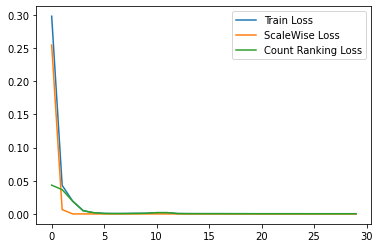

In [ ]:
torch.cuda.manual_seed(seed)
enc_model = Unet_encoder(n_channels, base_channel)
torch.cuda.manual_seed(seed)
triplet_model = TripletNet(enc_model)
torch.cuda.manual_seed(seed)
model = nn.DataParallel(triplet_model)
c_model = CountRankingModel().to(device)

Alpha = 0.05


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

validation_loss_min = np.Inf
train_loss_values = []
train_triplet_loss_values = []
train_count_loss_values = []

n_epochs = 30
for epoch in range(n_epochs):
    print('=========================================================')
    print('Epoch: {}'.format(epoch + 1))
    train_loss = 0
    model.train()
    t_loss_total = 0
    c_loss_total = 0
    for iteration, (anchor, positive, negative) in enumerate(train_loader):
        print_triplet = (to_print_trans(anchor[0, :, :, :].to('cpu')), to_print_trans(positive[0, :, :, :].to('cpu')), to_print_trans(negative[0, :, :, :].to('cpu')))
        # print('-- iteration: {}'.format(iteration))
        optimizer.zero_grad()
        # compute output
        out_a, out_p, out_n, _, u_model = model(anchor, positive, negative) 
        t_loss = tripletLoss(1, out_a, out_p, out_n , False) 
        c_loss = countLoss(c_model , 1 , out_p , out_n , False)
        loss = t_loss + Alpha*c_loss
        loss.sum().backward()
        optimizer.step()

        # update running train loss
        train_loss += loss.item()
        
        if iteration % validation_iteration == 0: 
            with torch.no_grad():
                is_training = model.training
                validation_loss = 0
                model.eval()

                for anchor, positive, negative in validation_loader:
                  out_a, out_p, out_n, temp_weights, u_model = model(anchor , positive, negative)
                  v_t_loss = tripletLoss(1, out_a, out_p, out_n)
                  v_c_loss = countLoss(c_model , 1 , out_p , out_n , False) 
                  loss = v_t_loss + Alpha*v_c_loss
                  # print("total_val_loss : {:.2f} , ScaleWizeLoss : {:.2f} CountLoss : {:.2f}".format( float(loss) , float(v_t_loss) ,float(v_c_loss) ))
                  # update running validation loss
                  validation_loss += loss.item()

                validation_loss = validation_loss / len(validation_loader.sampler)

                # save model if validation loss has decreased
                if validation_loss <= validation_loss_min:
                    print('\tValidation loss: {:.2f}'.format(validation_loss))
                    torch.save(u_model.state_dict(), 'model.pt')
                    model_weights = temp_weights
                    print('Model Saved')
                    validation_loss_min = validation_loss

                model.train(mode=is_training)
        t_loss_total += t_loss
        c_loss_total += Alpha*c_loss
    torch.save(u_model.state_dict(), 'latest.pt')
    train_loss = train_loss / len(train_loader.sampler)
    train_loss_values.append(train_loss)
    t_loss_total = float(t_loss_total)/len(train_loader.sampler)
    c_loss_total = float(c_loss_total)/len(train_loader.sampler)
    train_triplet_loss_values.append(t_loss_total)
    train_count_loss_values.append(c_loss_total)
    # show_images(print_triplet)
    print('Epoch: {} \tTraining Loss: {:.3f} \n\t\tScaleWizeLoss : {:.3f}\n\t\tCountLoss : {:.3f}'.format(epoch + 1, train_loss , t_loss_total , c_loss_total))

plot_loss(train_loss_values, train_triplet_loss_values, train_count_loss_values)

## Utils

In [ ]:
from skimage.morphology import label

def dice_coeff1(pred, target):
    smooth = 1.
    num = pred.size(0)
    m1 = pred.view(num, -1)  # Flatten
    m2 = target.view(num, -1)  # Flatten
    intersection = (m1 * m2).sum(1)

    return (2. * intersection + smooth) / (m1.sum(1) + m2.sum(1) + smooth)


def map_metric(y_true_in, y_pred_in, print_table=False):
    labels = label(y_true_in > 0.5)
    y_pred = label(y_pred_in > 0.5)

    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))

    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(), bins=(true_objects, pred_objects))[0]

    # Compute areas (needed for finding the union between all objects)
    area_true = np.histogram(labels, bins = true_objects)[0]
    area_pred = np.histogram(y_pred, bins = pred_objects)[0]
    area_true = np.expand_dims(area_true, -1)
    area_pred = np.expand_dims(area_pred, 0)

    # Compute union
    union = area_true + area_pred - intersection

    # Exclude background from the analysis
    intersection = intersection[1:,1:]
    union = union[1:,1:]
    union[union == 0] = 1e-9

    # Compute the intersection over union
    iou = intersection / union

    # Precision helper function
    def precision_at(threshold, iou):
        matches = iou > threshold
        true_positives = np.sum(matches, axis=1) == 1   # Correct objects
        false_positives = np.sum(matches, axis=0) == 0  # Missed objects
        false_negatives = np.sum(matches, axis=1) == 0  # Extra objects
        tp, fp, fn = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
        return tp, fp, fn

    # Loop over IoU thresholds
    prec = []
    if print_table:
        print("Thresh\tTP\tFP\tFN\tPrec.")
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        if (tp + fp + fn) > 0:
            p = tp / (tp + fp + fn)
        else:
            p = 0
        if print_table:
            print("{:1.3f}\t{}\t{}\t{}\t{:1.3f}".format(t, tp, fp, fn, p))
        prec.append(p)
    
    
    if print_table:
        print("AP\t-\t-\t-\t{:1.3f}".format(np.mean(prec)))
    return np.mean(prec)

def map_metric_batch(y_true_in, y_pred_in):
    batch_size = y_true_in.shape[0]
    metric = []
    for batch in range(batch_size):
        value = map_metric(y_true_in[batch], y_pred_in[batch])
        metric.append(value)
    
    result = np.array(np.mean(metric), dtype=np.float32)
    return result

In [ ]:
def standard_train(model, t_loader, v_loader, criterion, optimizer, scheduler=None, device='cuda:0',
          epochs=100, verbose=1, checkpoint=20, checkpoint_name='model'):
    model.train()
    
    log_train_loss = []
    log_val_loss = []
    log_val_score = []
    
    for epoch in tqdm(range(epochs)):
        train_loss = 0
        train_n = 0

        # TRAINING LOOP
        for train_batch in t_loader:
            x, y = train_batch
            x, y = x.float().to(device), y.float().to(device)

            outputs = model(x).float().to(device)
            loss = criterion(outputs, y)

            train_loss += loss.item() * y.size(0)
            train_n += y.size(0)

            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()
            optimizer.zero_grad()

        train_loss = train_loss / train_n

        log = '\r{}\ntrain_loss:{:.4f}\n'.format(epoch + 1, train_loss)

        val_loss, val_score = evaluate(model, v_loader, criterion, device)

        log += '  val_loss:{:.4f}\tval_score:{:.4f}\n'.format(val_loss, val_score)

        log_train_loss.append(train_loss)
        log_val_loss.append(val_loss)
        log_val_score.append(val_score)

        if (epoch + 1) % verbose == 0:
            print(log)

        if (epoch + 1) % checkpoint == 0:
            torch.save(model.state_dict(), f'{checkpoint_name}_epoch{epoch+1}.pth')
            print("Checkpoint", epoch+1, "saved!")

    return log_train_loss, log_val_loss, log_val_score

def evaluate(model, loader, criterion, device):
    model.eval()
    
    # VALIDATION LOOP
    with torch.no_grad():
        val_loss = 0
        val_score = 0
        val_n = 0

        for val_batch in loader:
            x, y = val_batch
            x, y = x.float().to(device), y.float().to(device)
            outputs = model(x).float().to(device)
            
            loss = criterion(outputs, y).item()
            score = map_metric_batch(outputs.cpu().detach(), y.cpu().detach())
            
            val_loss += loss * y.size(0)
            val_score += score * y.size(0)
            
            val_n += y.size(0)

        val_loss = val_loss / val_n
        val_score = val_score / val_n
        
    model.train()
    
    return val_loss, val_score

In [ ]:
en_model = Unet_encoder()
en_model.load_state_dict(torch.load('latest.pt'))
# print(en_model)
torch.cuda.manual_seed(seed)
model = Unet(n_classes, base_channel, en_model)
criterion = nn.BCEWithLogitsLoss() 

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)



In [ ]:
num_epochs = 300

In [ ]:
unet_log_train_loss, unet_log_val_loss, unet_log_val_score = standard_train(model.to(device), unet_train_loader , unet_validation_loader, criterion, optimizer,
                                                                            scheduler=None, device=device, epochs=num_epochs, 
                                                                            verbose=1, checkpoint=20, 
                                                                            checkpoint_name='512_standard_unet')


  0%|          | 1/300 [00:11<57:29, 11.54s/it]

1
train_loss:0.6486
  val_loss:0.4054	val_score:0.0000




  1%|          | 2/300 [00:23<57:17, 11.53s/it]

2
train_loss:0.3781
  val_loss:0.4012	val_score:0.0000




  1%|          | 3/300 [00:34<57:04, 11.53s/it]

...

181
train_loss:0.1017
  val_loss:0.1342	val_score:0.3968




 61%|██████    | 182/300 [35:02<22:45, 11.57s/it]

182
train_loss:0.0999
  val_loss:0.1656	val_score:0.3703




 61%|██████    | 183/300 [35:13<22:33, 11.57s/it]

183
train_loss:0.1025
  val_loss:0.1362	val_score:0.3921



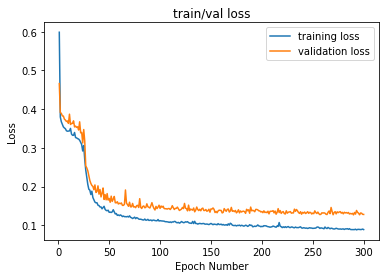

In [ ]:
plt.plot(range(1, num_epochs+1), unet_log_train_loss, color='C0', label="training loss")
plt.plot(range(1, num_epochs+1), unet_log_val_loss, color='C1', label="validation loss")
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.title("train/val loss")
plt.show()

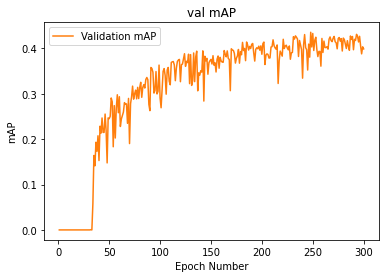

In [ ]:
plt.plot(range(1, num_epochs+1), unet_log_val_score, color='C1', label='Validation mAP')
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('mAP')
plt.title("val mAP")
plt.show()

In [ ]:
val_loss, val_score = evaluate(model, unet_validation_loader, criterion, device)
print("Validation mAP: {:.4f}".format(val_score))
print('Maximum validation mAP: {:.4f}'.format(np.max(unet_log_val_score)), '\tepoch:', np.argmax(unet_log_val_score)+1)

Validation mAP: 0.3987
Maximum validation mAP: 0.4354 	epoch: 248


In [ ]:
test_loss, test_score = evaluate(model, test_loader, criterion, device)
print("Test mAP: {:.4f}".format(test_score))
# print('Maximum Test mAP: {:.4f}'.format(np.max(unet_log_test_score)), '\tepoch:', np.argmax(unet_log_test_score)+1)

Test mAP: 0.2344


## Phase 3: Without Self-supervised Learning


In [ ]:
torch.cuda.manual_seed(seed)
en_model = Unet_encoder()
torch.cuda.manual_seed(seed)
model = Unet(n_classes, base_channel, en_model)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
unsup_log_train_loss, unsup_log_val_loss, unsup_log_val_score = standard_train(model.to(device), unet_train_loader , unet_validation_loader, criterion, optimizer,
                                                                            scheduler=None, device=device, epochs=num_epochs, 
                                                                            verbose=1, checkpoint=30, 
                                                                            checkpoint_name='512_unsupervised_unet')


  0%|          | 1/500 [00:11<1:35:42, 11.51s/it]

1
train_loss:0.6774
  val_loss:0.6747	val_score:0.0000




  0%|          | 2/500 [00:23<1:35:32, 11.51s/it]

2
train_loss:0.6598
  val_loss:0.5544	val_score:0.0000




  1%|          | 3/500 [00:34<1:35:19, 11.51s/it]

...

498
train_loss:0.0749
  val_loss:0.1196	val_score:0.4760




100%|█████████▉| 499/500 [1:35:55<00:11, 11.53s/it]

499
train_loss:0.0759
  val_loss:0.1218	val_score:0.4221




100%|██████████| 500/500 [1:36:07<00:00, 11.53s/it]

500
train_loss:0.0771
  val_loss:0.1223	val_score:0.4339



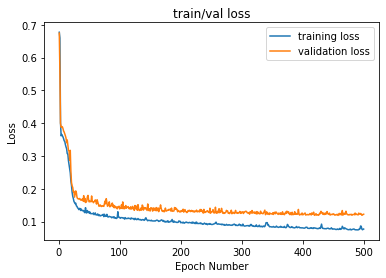

In [ ]:
plt.plot(range(1, num_epochs+1), unsup_log_train_loss, color='C0', label="training loss")
plt.plot(range(1, num_epochs+1), unsup_log_val_loss, color='C1', label="validation loss")
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.title("train/val loss")
plt.show()

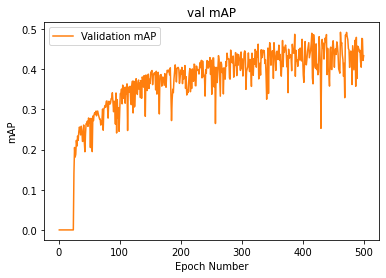

In [ ]:
plt.plot(range(1, num_epochs+1), unsup_log_val_score, color='C1', label='Validation mAP')
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('mAP')
plt.title("val mAP")
plt.show()

In [ ]:
unsup_val_loss, unsup_val_score = evaluate(model, unet_validation_loader, criterion, device)
print("Validation mAP: {:.4f}".format(unsup_val_score))
print('Maximum validation mAP: {:.4f}'.format(np.max(unsup_log_val_score)), '\tepoch:', np.argmax(unsup_log_val_score)+1)

Validation mAP: 0.4339
Maximum validation mAP: 0.4923 	epoch: 462


In [ ]:
unsup_val_loss, unsup_val_score = evaluate(model, test_loader, criterion, device)
print("Test mAP: {:.4f}".format(unsup_val_score))
# print('Maximum validation mAP: {:.4f}'.format(np.max(unsup_log_val_score)), '\tepoch:', np.argmax(unsup_log_val_score)+1)

Test mAP: 0.2608
